In [1]:
import pandas as pd
file1=pd.read_csv('Cellular_Towers.csv')
print("Rows in file1 =", len(file1))
print(file1.head())

Rows in file1 = 23498
   index          X          Y   FID  \
0      0 -86.505505  39.072207  8001   
1      1 -86.559405  39.180607  8002   
2      2 -86.610305  41.862808  8003   
3      3 -85.879405  42.861108  8004   
4      4 -85.909705  43.055608  8005   

                                      LICENSEE CALLSIGN  LOCNUM   LAT_DMS  \
0  GTE Mobilnet of Indiana Limited Partnership  KNKA642       3   39,4,20   
1  GTE Mobilnet of Indiana Limited Partnership  KNKA642       4  39,10,50   
2               New Cingular Wireless PCS, LLC  KNKA809       2  41,51,46   
3                                      New Par  KNKA375      11  42,51,40   
4                                      New Par  KNKA375      12   43,3,20   

  LATDIR   LON_DMS  ...       LOCCITY LOCCOUNTY LOCSTATE NEPA QZONE   TOWREG  \
0      N  86,30,20  ...    SMITHVILLE    MONROE       IN    N        1027709   
1      N  86,33,34  ...   BLOOMINGTON    MONROE       IN    N        1045327   
2      N  86,36,37  ...    THREE O

In [2]:
towers_df = file1[['FID', 'X', 'Y']].copy()

towers_df.rename(columns={
    'FID':'tower_id',
    'X':'lon',
    'Y':'lat'
}, inplace=True)

print("Extracted towers:")
print(towers_df.head())
print("Total towers =", len(towers_df))


Extracted towers:
   tower_id        lon        lat
0      8001 -86.505505  39.072207
1      8002 -86.559405  39.180607
2      8003 -86.610305  41.862808
3      8004 -85.879405  42.861108
4      8005 -85.909705  43.055608
Total towers = 23498


In [3]:
towers_df['radius'] = 3
towers = {
    row["tower_id"]: (row["lat"], row["lon"], row["radius"])
    for _, row in towers_df.iterrows()
}

print("Total towers in dict =", len(towers))


Total towers in dict = 23498


In [4]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)

    a = (math.sin(dlat/2)**2 +
         math.cos(math.radians(lat1)) *
         math.cos(math.radians(lat2)) *
         math.sin(dlon/2)**2)

    return 2 * R * math.asin(math.sqrt(a))


In [5]:
# Use only first 500 towers for testing
sample_towers_df = towers_df.head(500)

sample_towers = {
    row["tower_id"]: (row["lat"], row["lon"], row["radius"])
    for _, row in sample_towers_df.iterrows()
}

graph = {tower: [] for tower in sample_towers}

for t1 in sample_towers:
    for t2 in sample_towers:
        if t1 != t2:
            lat1, lon1, r1 = sample_towers[t1]
            lat2, lon2, r2 = sample_towers[t2]

            distance = haversine(lat1, lon1, lat2, lon2)

            if distance < (r1 + r2):  # Interference condition
                graph[t1].append(t2)

print("Graph built! Number of sample towers =", len(graph))


Graph built! Number of sample towers = 500


In [6]:
colors = {}
saturation = {v: 0 for v in graph}

while len(colors) < len(graph):

    uncolored = [v for v in graph if v not in colors]

    # Choose tower with highest saturation
    selected = max(
        uncolored,
        key=lambda v: (saturation[v], len(graph[v]))
    )

    # Find smallest available color (frequency)
    used = {colors[n] for n in graph[selected] if n in colors}

    color = 1
    while color in used:
        color += 1

    colors[selected] = color

    # Update saturation for neighbors
    for nb in graph[selected]:
        if nb not in colors:
            saturation[nb] = len({
                colors[n] for n in graph[nb] if n in colors
            })

print("DSATUR completed!")


DSATUR completed!


In [7]:
print("\nFrequency Allocation on 500 Towers:\n")

count = 0
for tower, freq in list(colors.items())[:20]:  # show first 20
    print(f"Tower {tower} → Frequency {freq}")
    count += 1

print("\nTotal frequencies used:", max(colors.values()))



Frequency Allocation on 500 Towers:

Tower 8268.0 → Frequency 1
Tower 8248.0 → Frequency 2
Tower 8297.0 → Frequency 3
Tower 8378.0 → Frequency 4
Tower 8362.0 → Frequency 3
Tower 8304.0 → Frequency 1
Tower 8280.0 → Frequency 2
Tower 8287.0 → Frequency 1
Tower 8338.0 → Frequency 2
Tower 8364.0 → Frequency 1
Tower 8193.0 → Frequency 1
Tower 8498.0 → Frequency 2
Tower 8150.0 → Frequency 3
Tower 8211.0 → Frequency 4
Tower 8192.0 → Frequency 2
Tower 8195.0 → Frequency 1
Tower 8069.0 → Frequency 1
Tower 8074.0 → Frequency 2
Tower 8108.0 → Frequency 2
Tower 8136.0 → Frequency 2

Total frequencies used: 4


In [8]:
import numpy as np

coords = np.radians(towers_df[['lat', 'lon']].values)


In [9]:
from sklearn.neighbors import BallTree

ball_tree = BallTree(coords, metric='haversine')

print("BallTree built successfully for", len(coords), "towers")


BallTree built successfully for 23498 towers


In [10]:
radius_km = 3
radius_rad = radius_km / 6371  # km → radians
neighbors = ball_tree.query_radius(coords, r=radius_rad)


In [11]:
graph = {}
tower_ids = towers_df['tower_id'].values

for i, nbr in enumerate(neighbors):
    t1 = tower_ids[i]
    # Include all neighbors except itself
    graph[t1] = [tower_ids[j] for j in nbr if j != i]

print("Graph built!")
print("Total towers in graph =", len(graph))


Graph built!
Total towers in graph = 23498


In [12]:
colors = {}
saturation = {node: 0 for node in graph}

count = 0  # progress counter

while len(colors) < len(graph):

    uncolored = [v for v in graph if v not in colors]

    selected = max(
        uncolored,
        key=lambda v: (saturation[v], len(graph[v]))
    )

    used = {colors[n] for n in graph[selected] if n in colors}

    color = 1
    while color in used:
        color += 1

    colors[selected] = color

    # update neighbors
    for nb in graph[selected]:
        if nb not in colors:
            saturation[nb] = len({
                colors[n] for n in graph[nb] if n in colors
            })

    # Print progress every 500 towers
    count += 1
    if count % 500 == 0:
        print("Colored", count, "towers...")


Colored 500 towers...
Colored 1000 towers...
Colored 1500 towers...
Colored 2000 towers...
Colored 2500 towers...
Colored 3000 towers...
Colored 3500 towers...
Colored 4000 towers...
Colored 4500 towers...
Colored 5000 towers...
Colored 5500 towers...
Colored 6000 towers...
Colored 6500 towers...
Colored 7000 towers...
Colored 7500 towers...
Colored 8000 towers...
Colored 8500 towers...
Colored 9000 towers...
Colored 9500 towers...
Colored 10000 towers...
Colored 10500 towers...
Colored 11000 towers...
Colored 11500 towers...
Colored 12000 towers...
Colored 12500 towers...
Colored 13000 towers...
Colored 13500 towers...
Colored 14000 towers...
Colored 14500 towers...
Colored 15000 towers...
Colored 15500 towers...
Colored 16000 towers...
Colored 16500 towers...
Colored 17000 towers...
Colored 17500 towers...
Colored 18000 towers...
Colored 18500 towers...
Colored 19000 towers...
Colored 19500 towers...
Colored 20000 towers...
Colored 20500 towers...
Colored 21000 towers...
Colored 2150

In [13]:
print("\nDSATUR Complete!")
print("Total Towers:", len(colors))
print("Total Frequencies Used:", max(colors.values()))



DSATUR Complete!
Total Towers: 23498
Total Frequencies Used: 9


In [14]:
from collections import Counter

freq_count = Counter(colors.values())

print("Frequency Distribution:")
for freq, count in freq_count.items():
    print(f"Frequency {freq}: {count} towers")


Frequency Distribution:
Frequency 1: 18260 towers
Frequency 2: 4465 towers
Frequency 3: 624 towers
Frequency 4: 120 towers
Frequency 5: 19 towers
Frequency 6: 7 towers
Frequency 7: 1 towers
Frequency 8: 1 towers
Frequency 9: 1 towers


In [15]:
output_df = pd.DataFrame({
    'tower_id': list(colors.keys()),
    'assigned_frequency': list(colors.values())
})

output_df.to_csv("frequency_allocation_file1.csv", index=False)

print("Saved to frequency_allocation_file1.csv")


Saved to frequency_allocation_file1.csv


In [16]:
def check_interference():
    conflicts = 0
    for t in graph:
        for nb in graph[t]:
            if colors[t] == colors[nb]:  # same color on neighbors → conflict
                conflicts += 1
    return conflicts

conflicts = check_interference()
print("Interference Conflicts:", conflicts)


Interference Conflicts: 0


In [17]:
print("Total Towers:", len(graph))
print("Total Edges (Interference Links):", sum(len(v) for v in graph.values()) // 2)
print("Colors Used:", max(colors.values()))


Total Towers: 23498
Total Edges (Interference Links): 6286
Colors Used: 9


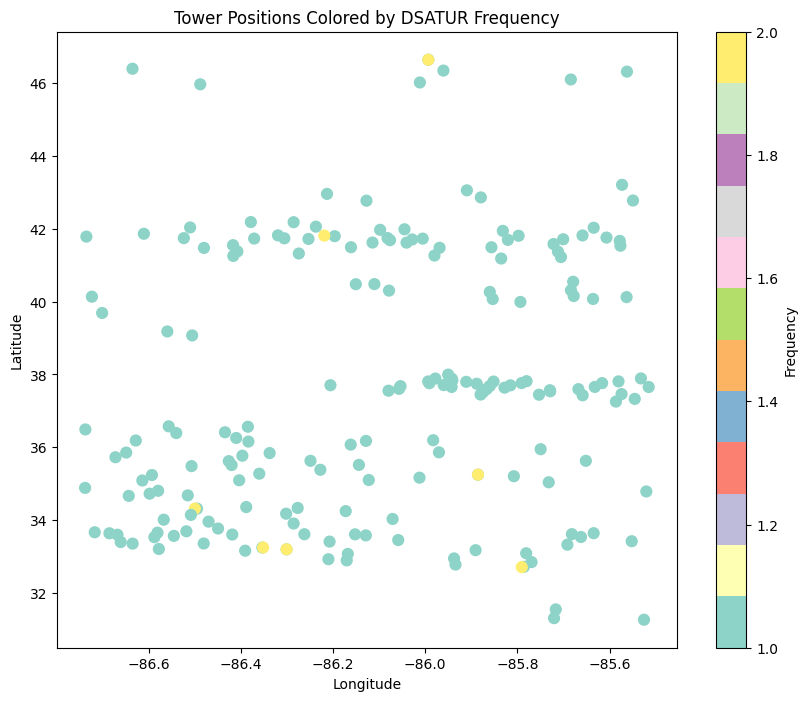

In [18]:
import matplotlib.pyplot as plt

sub_df = towers_df.head(200)  # first 200 with coordinates

plt.figure(figsize=(10, 8))
plt.scatter(sub_df['lon'], sub_df['lat'],
            c=[colors[t] for t in sub_df['tower_id']],
            cmap='Set3', s=60)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Tower Positions Colored by DSATUR Frequency")
plt.colorbar(label="Frequency")
plt.show()


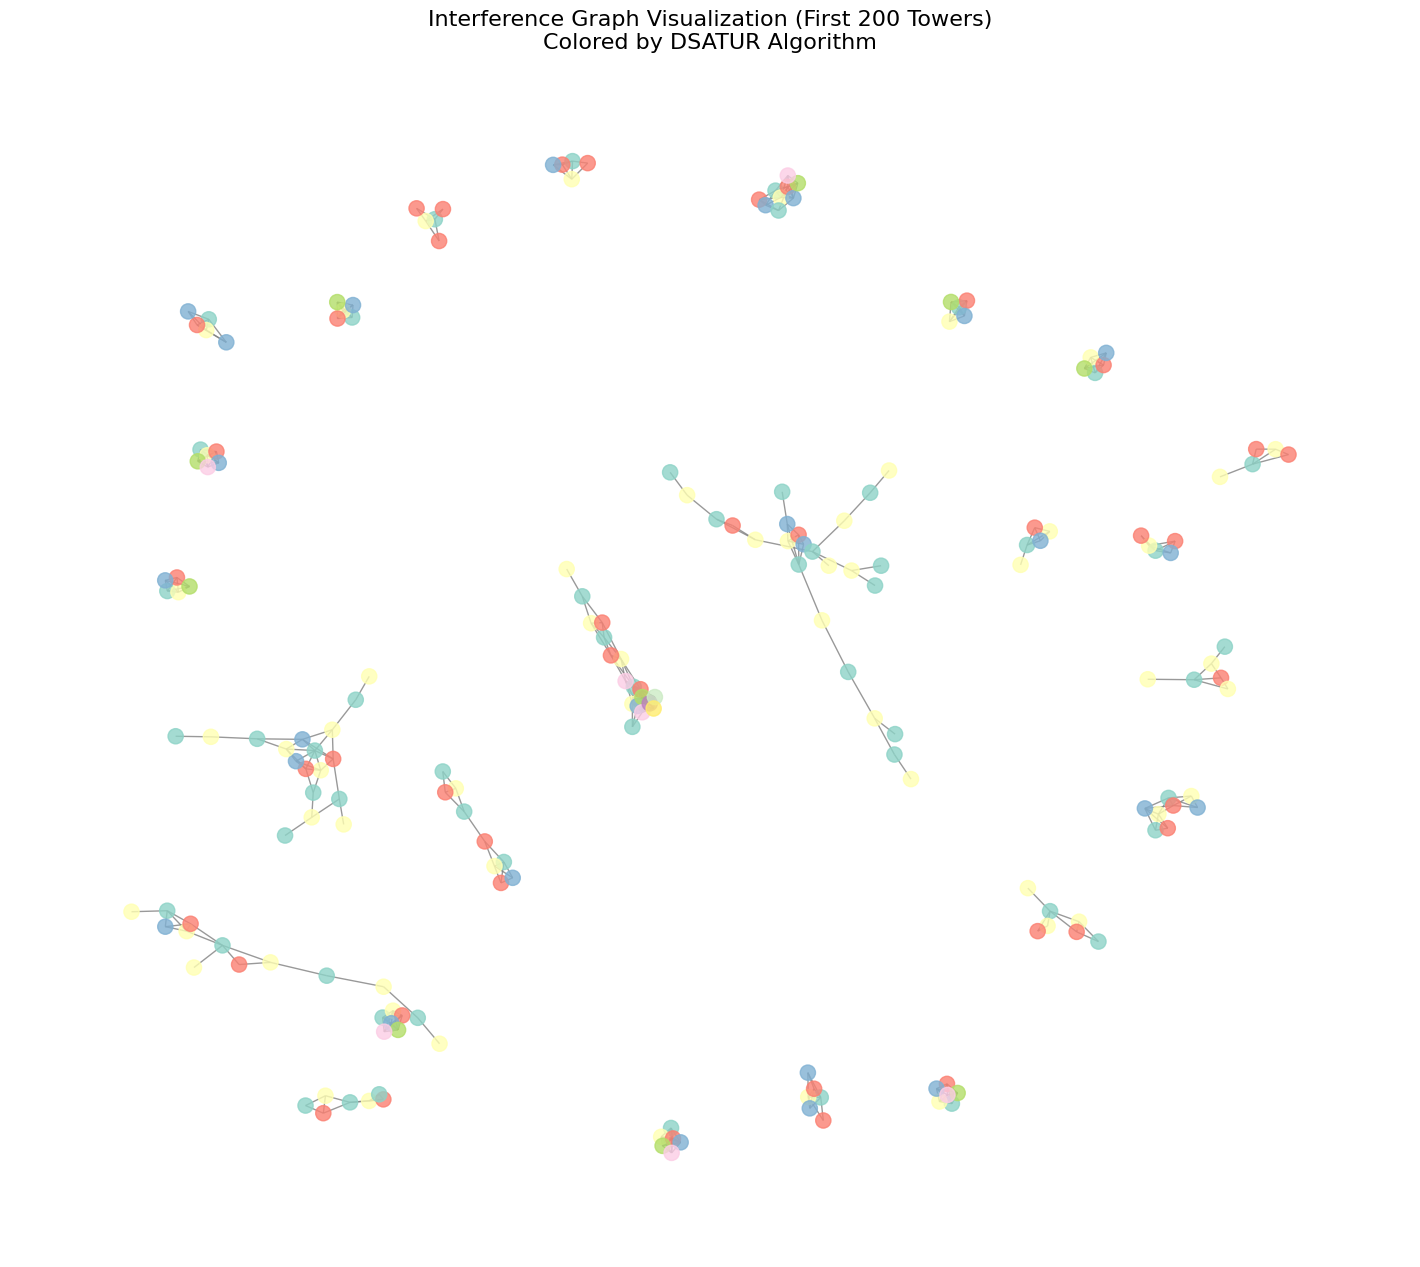

In [19]:
import networkx as nx
import matplotlib.pyplot as plt

# SELECT SUBSET FOR VISUALIZATION
visual_nodes = list(colors.keys())[:200]

G = nx.Graph()

# Add nodes
for t in visual_nodes:
    G.add_node(t)

# Add edges
for t in visual_nodes:
    for nb in graph[t]:
        if nb in visual_nodes:
            G.add_edge(t, nb)

# Node colors based on DSATUR frequencies
node_colors = [colors[t] for t in visual_nodes]

# DRAW GRAPH
plt.figure(figsize=(14, 12))
nx.draw(
    G,
    node_color=node_colors,
    cmap=plt.cm.Set3,
    with_labels=False,
    node_size=120,
    edge_color="gray",
    alpha=0.8
)

plt.title("Interference Graph Visualization (First 200 Towers)\nColored by DSATUR Algorithm", fontsize=16)
plt.show()
